In [ ]:
pip install xgboost

In [49]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import   XGBClassifier


In [7]:
import warnings 
warnings.filterwarnings('ignore')

In [8]:
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('crop_recommendation.csv')
df.sample(5)

,N,P,K,temperature,humidity,ph,rainfall,label
363,37,74,15,24.923601,18.225908,5.582178,62.708917,kidneybeans
460,34,75,24,23.502228,51.290195,4.760038,192.302399,pigeonpeas
204,36,67,77,18.369526,19.563810,7.152811,79.263577,chickpea
469,19,57,23,23.673433,47.287969,7.342410,141.125072,pigeonpeas
1704,31,68,45,42.923253,90.076005,6.938313,196.240824,papaya


In [4]:
df.shape

(2200, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [6]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [9]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


Average Nitrogen: 50.55
Maximum Nitrogen 140
Minimum Nitrogen 0


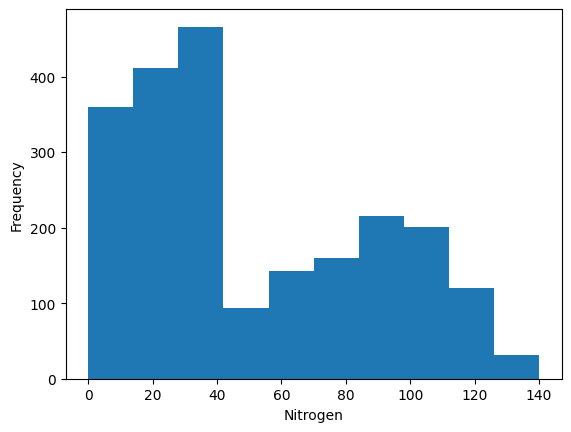

In [11]:
# Nitrogen Analysis
print("Average Nitrogen:",df['N'].mean().round(2))
print("Maximum Nitrogen",df['N'].max())
print("Minimum Nitrogen",df['N'].min())

plt.Figure()
plt.hist(df['N'])
plt.title("Nitrogen (N) level distribution")
plt.xlabel("Nitrogen level")
plt.ylabel("Frequency")
plt.show()

Average Phosphurus: 53.36
Maximum Phosphurus: 145
Minimum Phosphurus: 5


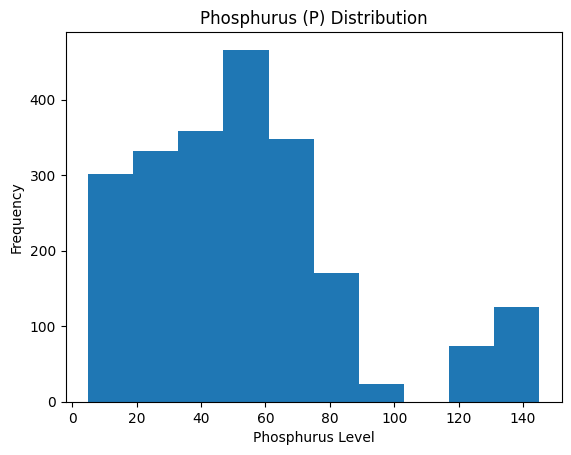

In [12]:
#Phosphurus Analysis
print("Average Phosphurus:",df['P'].mean().round(2))
print("Maximum Phosphurus:",df['P'].max())
print("Minimum Phosphurus:",df['P'].min())
plt.Figure()
plt.hist(df['P'])
plt.title("Phosphurus (P) Distribution")
plt.xlabel('Phosphurus Level')
plt.ylabel("Frequency")
plt.show()

Average Potasium: 48.15
Maximum Potasium: 205
Minimum Potasium: 5


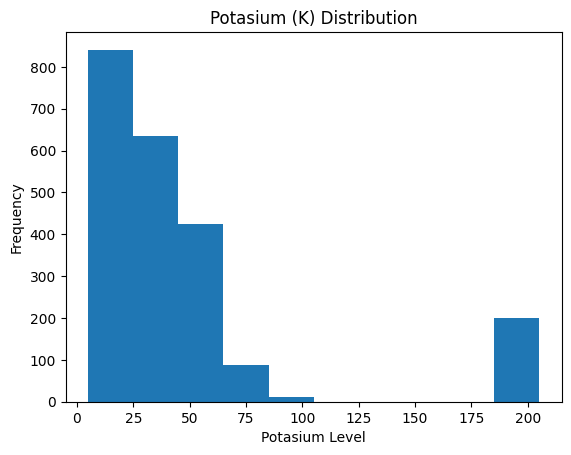

In [14]:
# Potasium(k) Analysis
print("Average Potasium:",df['K'].mean().round(2))
print("Maximum Potasium:",df['K'].max())
print("Minimum Potasium:",df['K'].min())
plt.Figure()
plt.hist(df['K'])
plt.title("Potasium (K) Distribution")
plt.xlabel('Potasium Level')
plt.ylabel("Frequency")
plt.show()

Temperature Analysis
Average temperature: 25.62
Maximum temperature: 43.67549305
Minimum temperature: 8.825674745


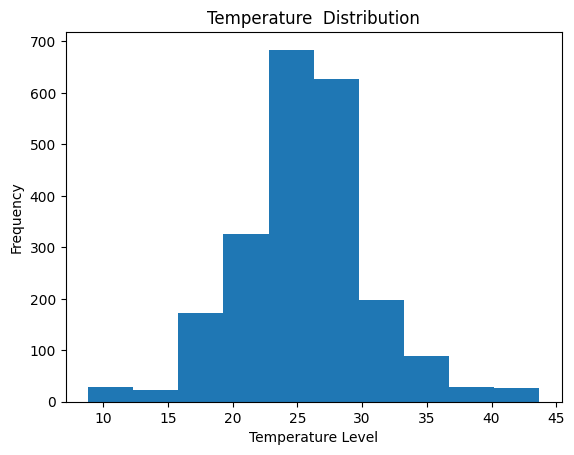

In [15]:
# Temperature analysis
print('Temperature Analysis')
print("Average temperature:",df['temperature'].mean().round(2))
print("Maximum temperature:",df['temperature'].max())
print("Minimum temperature:",df['temperature'].min())
plt.Figure()
plt.hist(df['temperature'])
plt.title("Temperature  Distribution")
plt.xlabel('Temperature Level')
plt.ylabel("Frequency")
plt.show()

Humidity Analysis
Temperature Analysis
Average humidity: 71.48
Maximum humidity: 99.98187601
Minimum humidity: 14.25803981


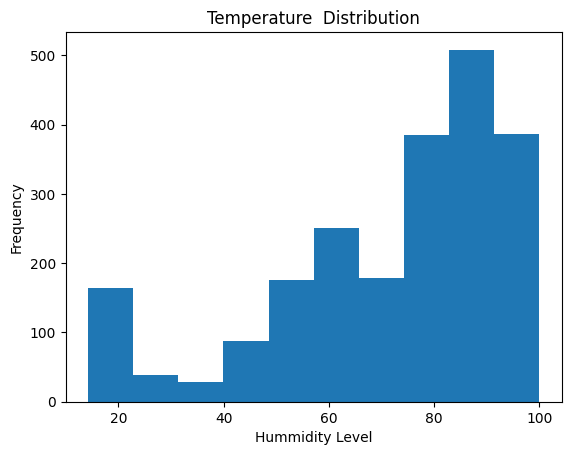

In [16]:
print("Humidity Analysis")
print('Temperature Analysis')
print("Average humidity:",df['humidity'].mean().round(2))
print("Maximum humidity:",df['humidity'].max())
print("Minimum humidity:",df['humidity'].min())
plt.Figure()
plt.hist(df['humidity'])
plt.title("Temperature  Distribution")
plt.xlabel('Hummidity Level')
plt.ylabel("Frequency")
plt.show()

Rainfall Analysis
Average rainfall: 103.46
Maximum rainfall: 298.5601175
Minimum rainfall: 20.21126747


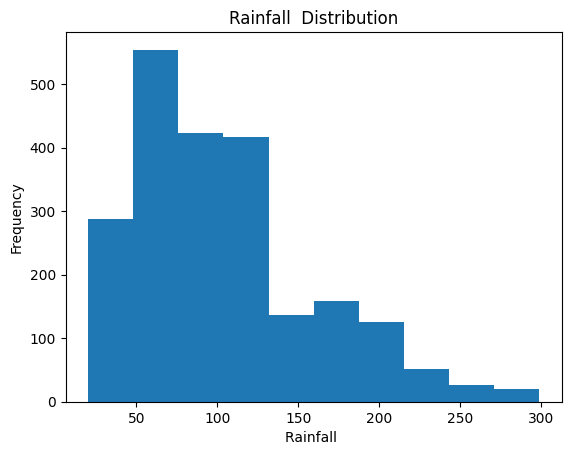

In [17]:
print('Rainfall Analysis')
print("Average rainfall:",df['rainfall'].mean().round(2))
print("Maximum rainfall:",df['rainfall'].max())
print("Minimum rainfall:",df['rainfall'].min())
plt.Figure()
plt.hist(df['rainfall'])
plt.title("Rainfall  Distribution")
plt.xlabel('Rainfall ')
plt.ylabel("Frequency")
plt.show()

PH Analysis
Average Ph: 6.47
Maximum Ph: 9.93509073
Minimum Ph: 3.504752314


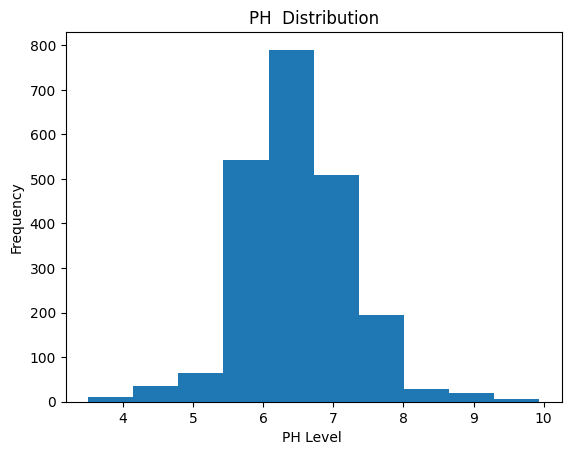

In [18]:
print('PH Analysis')
print("Average Ph:",df['ph'].mean().round(2))
print("Maximum Ph:",df['ph'].max())
print("Minimum Ph:",df['ph'].min())
plt.Figure()
plt.hist(df['ph'])
plt.title("PH  Distribution")
plt.xlabel('PH Level ')
plt.ylabel("Frequency")
plt.show()

In [19]:
df.sample()


,N,P,K,temperature,humidity,ph,rainfall,label
186,65,60,22,25.367684,72.520546,6.606984,107.912411,maize


In [24]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

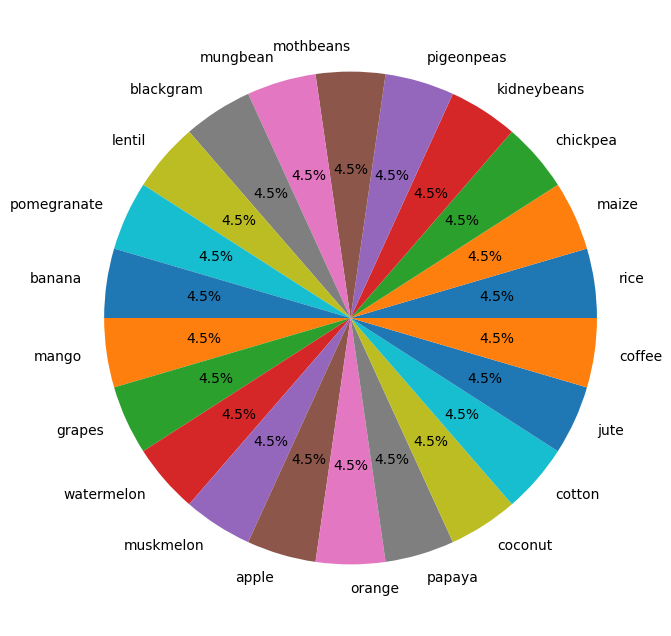

In [23]:
crop_list = df['label'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    crop_list.values,
    labels=crop_list.index,
    autopct='%1.1f%%'
)

plt.show()

In [30]:
from sklearn.model_selection import train_test_split

In [29]:
# Training The Model
X=df.drop(columns='label') ## Input Data
y=df['label'] #Output Data

0         rice
1         rice
2         rice
3         rice
4         rice
         ...  
2195    coffee
2196    coffee
2197    coffee
2198    coffee
2199    coffee
Name: label, Length: 2200, dtype: str


In [31]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=300)

In [37]:
acc=[]
model=[]

Logistic Regression

In [ ]:
log_model=LogisticRegression()
log_model.fit(X_train,y_train)
y_predct=log_model.predict(X_test)

accuracy=accuracy_score(y_test,y_predct)
acc.append(accuracy)
model.append('Logistic Regression')
print("Logistic regression accuracy",accuracy*100)
print('classification_report',classification_report(y_predct,y_test))

In [41]:
# Decision Tree

dt_model=DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
y_predct=dt_model.predict(X_test)
accuracy=accuracy_score(y_test,y_predct)
acc.append(accuracy)
model.append('Decision Tree')

print('Accuracy of decision tree',accuracy*100)
print('classification_report', classification_report(y_test,y_predct))

Accuracy of decision tree 98.86363636363636
classification_report               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        24
      banana       1.00      1.00      1.00        22
   blackgram       1.00      1.00      1.00        28
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        25
      coffee       1.00      1.00      1.00        14
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        18
        jute       0.89      0.89      0.89        19
 kidneybeans       1.00      1.00      1.00        21
      lentil       0.96      1.00      0.98        23
       maize       1.00      1.00      1.00        16
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.95      0.98        22
    mungbean       1.00      1.00      1.00        17
   muskmelon       1.00      1.00      1.00        14
      orange   

In [45]:
## Random forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=300)
rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)
rf_acc =accuracy_score(y_test, pred_rf)

acc.append(rf_acc)
model.append('Random Forest')

print("Random Forest Accuracy is", rf_acc * 100)
print(classification_report(y_test, pred_rf))

Random Forest Accuracy is 99.31818181818181
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        24
      banana       1.00      1.00      1.00        22
   blackgram       1.00      1.00      1.00        28
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        25
      coffee       1.00      1.00      1.00        14
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        18
        jute       0.90      1.00      0.95        19
 kidneybeans       1.00      1.00      1.00        21
      lentil       0.96      1.00      0.98        23
       maize       1.00      1.00      1.00        16
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.95      0.98        22
    mungbean       1.00      1.00      1.00        17
   muskmelon       1.00      1.00      1.00        14
      orange       1.00      1.00    

In [46]:
from sklearn.preprocessing import LabelEncoder

In [51]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])

# Split again with encoded y
x_train1, x_test1, y_train1, y_test1 = train_test_split(
    X, y_encoded, test_size=0.20, random_state=300
)

In [52]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=300)
xgb_model.fit(x_train1, y_train1)

pred_xgb = xgb_model.predict(x_test1)
xgb_acc = accuracy_score(y_test1, pred_xgb)

acc.append(xgb_acc)
model.append('XGBoost')

print("XGBoost Accuracy is", xgb_acc * 100)
print(classification_report(y_test1, pred_xgb))

XGBoost Accuracy is 98.86363636363636
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        22
           2       0.97      1.00      0.98        28
           3       1.00      1.00      1.00        21
           4       0.96      1.00      0.98        25
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        15
           7       1.00      1.00      1.00        18
           8       0.95      1.00      0.97        19
           9       1.00      1.00      1.00        21
          10       1.00      0.96      0.98        23
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        19
          13       1.00      1.00      1.00        22
          14       1.00      1.00      1.00        17
          15       1.00      1.00      1.00        14
          16       1.00      1.00      1.00

In [ ]:
model_selection=pd.DataFrame({
    'Model':model,
    "Accuracy":acc
})


In [55]:
# Model comparision
print("Model comparision",model_selection)

Model comparision                  Model  Accuracy
0  Logistic Regression  0.959091
1  Logistic Regression  0.959091
2  Logistic Regression  0.959091
3        Decision Tree  0.988636
4        Random Forest  0.993182
5              XGBoost  0.988636


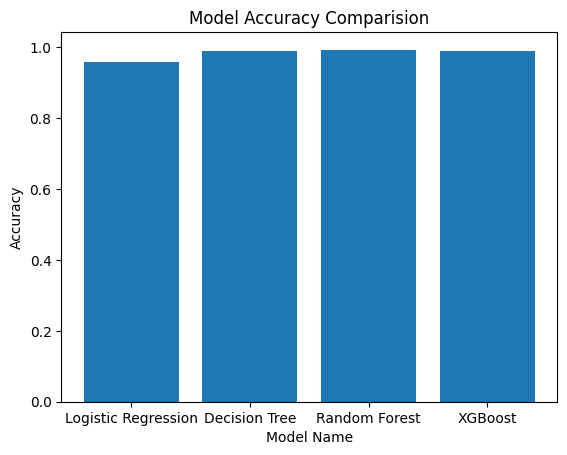

In [54]:
# Ploting which  Model has most accuracy that we can select  the model for training data
plt.figure()
plt.bar(model_selection['Model'],model_selection['Accuracy'])
plt.xlabel("Model Name")
plt.ylabel('Accuracy')
plt.title("Model Accuracy Comparision")
plt.show()

In [59]:
df.sample()

,N,P,K,temperature,humidity,ph,rainfall,label
938,5,24,40,24.692258,93.870301,6.297908,104.673545,pomegranate


In [56]:
# Now we are gonna choose Random forest since it has highest accuracy
import joblib

In [57]:
joblib.dump(rf_model,'crop_recommendation.joblib')

['crop_recommendation.joblib']

In [58]:
## testing the model
model=joblib.load('crop_recommendation.joblib')

In [ ]:
prediction=model.predict([[80,90,100,40,98,8,110]])
print(prediction)

['papaya']


: 